### Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [4]:
# Load the dataset
 
df = pd.read_csv("housing.csv")
 
print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (5000, 7)

First 5 rows:


,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.45857,5.682861,7.009188,4.09,23086.80050,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.64245,6.002900,6.730821,3.09,40173.07217,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.06718,5.865890,8.512727,5.13,36882.15940,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.24005,7.188236,5.586729,3.26,34310.24283,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.19723,5.040555,7.839388,4.23,26354.10947,6.309435e+05,USNS Raymond\nFPO AE 09386


In [5]:
# Check for missing values — clean data means no extra work needed
 
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
Avg. Area Income                0
Avg. Area House Age             0
Avg. Area Number of Rooms       0
Avg. Area Number of Bedrooms    0
Area Population                 0
Price                           0
Address                         0
dtype: int64


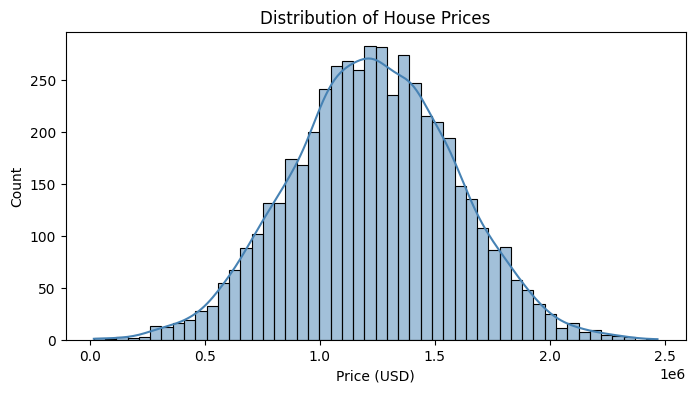

In [6]:
# EDA — distribution of house prices (what we want to predict)
 
plt.figure(figsize=(8, 4))
sns.histplot(df["Price"], bins=50, kde=True, color="steelblue")
plt.title("Distribution of House Prices")
plt.xlabel("Price (USD)")
plt.ylabel("Count")
plt.show()

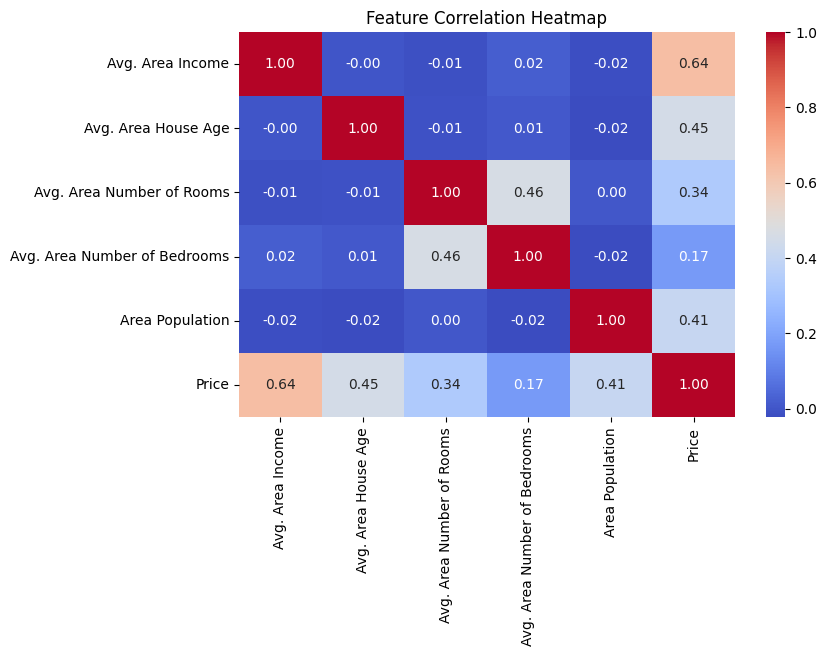

In [7]:
# Correlation heatmap 
 
plt.figure(figsize=(8, 5))
numeric_df = df.drop("Address", axis=1)  # drop text column before correlation
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

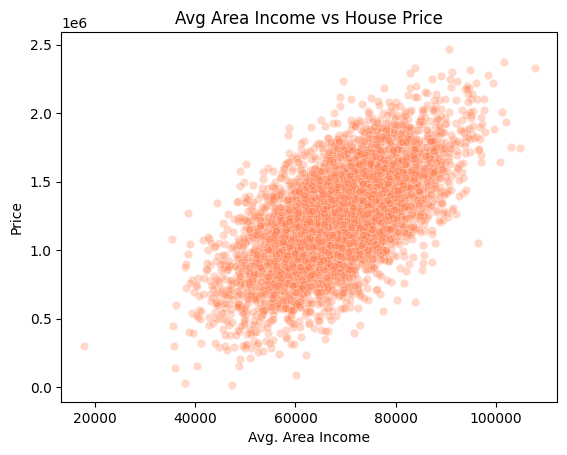

In [9]:
# Income vs Price — expect a strong positive relationship
 
sns.scatterplot(x="Avg. Area Income", y="Price", data=df, alpha=0.3, color="coral")
plt.title("Avg Area Income vs House Price")
plt.xlabel("Avg. Area Income")
plt.ylabel("Price")
plt.show()

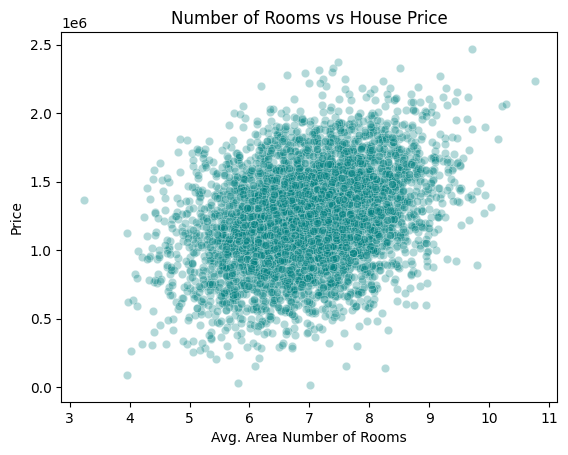

In [10]:
# Number of rooms vs Price
 
sns.scatterplot(x="Avg. Area Number of Rooms", y="Price", data=df, alpha=0.3, color="teal")
plt.title("Number of Rooms vs House Price")
plt.xlabel("Avg. Area Number of Rooms")
plt.ylabel("Price")
plt.show()

In [11]:
# Prepare features and target
 
X = df.drop(["Price", "Address"], axis=1)
y = df["Price"]
 
print("Features used:", X.columns.tolist())
 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
 
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Features used: ['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms', 'Avg. Area Number of Bedrooms', 'Area Population']
Training samples: 4000
Testing samples: 1000


In [13]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # fit on train, then transform
X_test_scaled = scaler.transform(X_test)         # only transform test

# Model 1: Linear Regression 
 
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
 
y_pred_lr = lr.predict(X_test_scaled)
 
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
 
print("Linear Regression:")
print(f"  MAE  = ${mae_lr:,.2f}")
print(f"  RMSE = ${rmse_lr:,.2f}")

Linear Regression:
  MAE  = $80,879.10
  RMSE = $100,444.06


In [14]:
# Model 2: Gradient Boosting
# Tree models don't need scaling so we use original X_train here
 
gb = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb.fit(X_train, y_train)
 
y_pred_gb = gb.predict(X_test)
 
mae_gb = mean_absolute_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
 
print("Gradient Boosting:")
print(f"  MAE  = ${mae_gb:,.2f}")
print(f"  RMSE = ${rmse_gb:,.2f}")

Gradient Boosting:
  MAE  = $87,417.53
  RMSE = $109,468.44


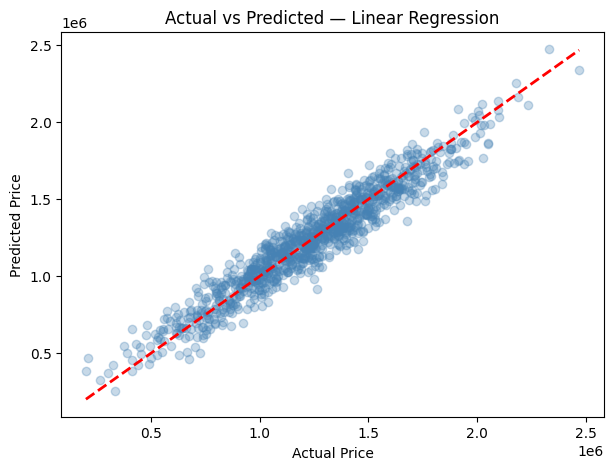

In [15]:
# Plot: Actual vs Predicted prices for Linear Regression
# Points closer to the red diagonal = better predictions
 
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred_lr, alpha=0.3, color="steelblue")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], "r--", lw=2)  # perfect prediction line
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted — Linear Regression")
plt.show()

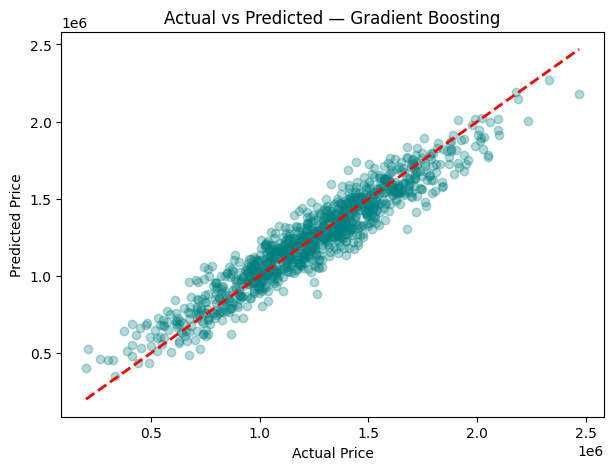

In [16]:
# Plot: Actual vs Predicted prices for Gradient Boosting
 
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred_gb, alpha=0.3, color="teal")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], "r--", lw=2)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted — Gradient Boosting")
plt.show()
 

C:\Users\Computer Arena\AppData\Local\Temp\ipykernel_12280\504288101.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importance", y="Feature", data=feat_df, palette="magma")


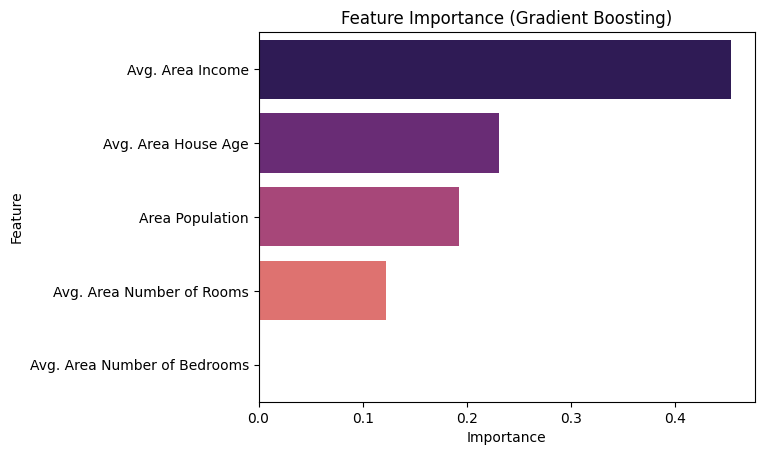

In [17]:
# Feature importance — what drives house prices the most?
 
importances = gb.feature_importances_
feat_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
}).sort_values("Importance", ascending=False)
 
sns.barplot(x="Importance", y="Feature", data=feat_df, palette="magma")
plt.title("Feature Importance (Gradient Boosting)")
plt.show()

In [18]:
# Final comparison of both models
 
print("=" * 50)
print("MODEL COMPARISON")
print("=" * 50)
print(f"{'Model':<25} {'MAE':>12} {'RMSE':>12}")
print("-" * 50)
print(f"{'Linear Regression':<25} ${mae_lr:>11,.2f} ${rmse_lr:>11,.2f}")
print(f"{'Gradient Boosting':<25} ${mae_gb:>11,.2f} ${rmse_gb:>11,.2f}")
print("=" * 50)
print("\nLower MAE and RMSE = better model")
print(f"\nTop feature driving prices: {feat_df.iloc[0]['Feature']}")

MODEL COMPARISON
Model                              MAE         RMSE
--------------------------------------------------
Linear Regression         $  80,879.10 $ 100,444.06
Gradient Boosting         $  87,417.53 $ 109,468.44

Lower MAE and RMSE = better model

Top feature driving prices: Avg. Area Income
